In [ ]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import property_driven_ml.logics as logics
import property_driven_ml.training as training

from withProperties.attack_ import (
    DoSHttpFloodPostcondition,
    TabularRuleConstraint,
    PortscanPostcondition,
    GlobalBounds
)
from sklearn.model_selection import train_test_split
from utils.utils import *
from sklearn.preprocessing import MinMaxScaler
from utils.models import build_model
from specs import ATTACK_SPECS
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]
PROPERTY_MODEL_FEATURES = MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES
FEATURE_COLS = PROPERTY_MODEL_FEATURES

label_to_idx = {label: i for i, label in enumerate(TARGET_LABELS)}
idx = {name: i for i, name in enumerate(FEATURE_COLS)}

BOOLEAN_FEATURES = ["valid_tcp_handshake", "valid_http_conn"]
FROZEN_FEATURES = [
    "valid_tcp_handshake",
    "valid_http_conn"
]

FROZEN_IDXS = [idx[f] for f in FROZEN_FEATURES if f in idx]

BATCH_SIZE = 1024
RANDOM_STATE = 42
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

LAMBDA_DOS = 0.5
LAMBDA_SCAN = 0.1
PGD_STEPS = 10
PGD_RESTARTS = 1
PGD_STEP_SIZE = 0.01
PATIENCE = 5
MIN_DELTA = 1e-4

In [26]:
raw_train_df = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_cicids2017 = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
dataset_name = "CICIoT2023"
print(raw_train_df)

print_section("Loading data")
print_df_summary(raw_train_df, "Raw " + dataset_name + " train")

train_full_df = filter_labels(raw_train_df, TARGET_LABELS, label_to_idx)

print("Training set label distribution before split:")
print_label_distribution(train_full_df)

train_val_df, test_df = train_test_split(
    train_full_df,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=train_full_df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df["label"],
)

                   ts                 uid                  id.orig_h  \
0        1.660668e+09  Ch3ncG1kMRNM7V7Bz8             192.168.137.17   
1        1.660671e+09  CGoYkg1Yv95df4aHR5            192.168.137.178   
2        1.660680e+09  CBMKGc4I6qc5R9ZlAj            192.168.137.109   
3        1.664870e+09  CL1qy43yrQxloFa1Ze             192.168.137.41   
4        1.660680e+09  CS3uF51AyiZ2Qng7xk             192.168.137.15   
...               ...                 ...                        ...   
2922692  1.665263e+09  Ct7pfv3x32wzezGTY9  fe80::ea1b:69ff:fef8:d6e6   
2922693  1.665263e+09  CTx2a14SfJoHvctCWb  fe80::ea1b:69ff:fef8:d6e6   
2922694  1.665264e+09  CvsxK23jNjRXUhJHM3  fe80::ea1b:69ff:fef8:d6e6   
2922695  1.665264e+09   CvSVOTt5PvkZvZN5h  fe80::ea1b:69ff:fef8:d6e6   
2922696  1.661974e+09  CIVnGJ3u0JyzJWSdU6  fe80::ea1b:69ff:fef8:d6e6   

         id.orig_p        id.resp_h  id.resp_p proto service    duration  \
0            22777  192.168.137.123       4070   tcp       

# Scaling and Dataloaders

In [27]:
def make_loader(df: pd.DataFrame, feature_cols: list[str], batch_size: int = 1024, shuffle: bool = False) -> DataLoader:
    x = torch.tensor(df[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(df["label_id"].to_numpy(), dtype=torch.long)
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def scale_value(col, raw_value, scaler, scale_cols):
    i = scale_cols.index(col)
    min_ = scaler.data_min_[i]
    max_ = scaler.data_max_[i]
    return (raw_value - min_) / (max_ - min_ + 1e-8)


def make_scaled_attack_specs(raw_specs: dict, scaler, scale_cols: list[str]) -> dict:
    specs = copy.deepcopy(raw_specs)
    scale_map = {
        "validity": {
            "valid_packet_size_min_pkts": "orig_pkts",
            "valid_packet_size_min_total_bytes": "orig_bytes",
        },
        "dos_http_flood": {
            "mal_time_elapsed_min": "time_elapsed",
            "mal_time_elapsed_max": "time_elapsed",
            "valid_pkt_size_total_min": "orig_bytes",
            "mal_byte_rate_min": "orig_byte_rate",
            "mal_pkt_rate_min": "orig_pkt_rate",
        },
        "portscan": {
            "min_uniq_dst_ports": "uniq_dst_ports",
            "max_pkts_per_port": "pkts_per_port",
            "max_scan_duration": "scan_duration",
            "min_fail_ratio": "fail_ratio",
        },
    }

    for attack_name, key_to_col in scale_map.items():
        for spec_key, col in key_to_col.items():
            specs[attack_name][spec_key] = scale_value(col, raw_specs[attack_name][spec_key], scaler, scale_cols)

    return specs

In [28]:
scale_cols = [col for col in FEATURE_COLS if col not in BOOLEAN_FEATURES]
scaler = MinMaxScaler()
# Clip outliers to the 1st and 99th percentiles before scaling
train_df[scale_cols] = train_df[scale_cols].clip(lower=train_df[scale_cols].quantile(0.01), upper=train_df[scale_cols].quantile(0.99), axis=1,)
test_df[scale_cols] = test_df[scale_cols].clip(lower=test_df[scale_cols].quantile(0.01), upper=test_df[scale_cols].quantile(0.99), axis=1,)
val_df[scale_cols] = val_df[scale_cols].clip(lower=val_df[scale_cols].quantile(0.01), upper=val_df[scale_cols].quantile(0.99), axis=1,)

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])
val_df[scale_cols] = scaler.transform(val_df[scale_cols])

scaled_attack_specs = make_scaled_attack_specs(ATTACK_SPECS, scaler, scale_cols)

train_loader = make_loader(train_df, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=True)
test_loader = make_loader(test_df, FEATURE_COLS, batch_size=BATCH_SIZE)
val_loader = make_loader(val_df, FEATURE_COLS, batch_size=BATCH_SIZE)

In [29]:
scaled_attack_specs["portscan"]

{'min_uniq_dst_ports': np.float64(0.019019019018828638),
 'max_pkts_per_port': np.float64(0.0013761467889887215),
 'max_scan_duration': np.float64(0.016474530911736503),
 'min_fail_ratio': np.float64(0.7499999925000002)}

In [30]:
train_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_http_conn,orig_pkt_rate,orig_byte_rate,window_id,is_failed_conn,uniq_dst_ports,pkts_per_port,scan_duration,fail_ratio,label_id
2197445,1.664288e+09,C9hfY7vP8sOX4Tzcc,192.168.137.178,36492,192.168.137.226,1154,tcp,-,0.001473,0.000000,...,0,0.000004,0.000000,332857505,1,0.989990,0.000061,0.001152,1.000000,2
2483740,1.665255e+09,Ciu33KGHYyyl3RL8d,192.168.137.39,40144,47.254.14.172,443,tcp,ssl,0.007344,0.019586,...,1,0.000014,0.036106,333051029,0,0.002002,0.000917,0.003668,0.000000,0
2010228,1.665164e+09,CvdoU3sBBIBIujIQh,192.168.137.133,21155,47.112.162.49,32100,udp,-,0.001904,0.000098,...,0,0.000003,0.000700,333032761,0,0.002002,0.000153,0.000951,0.166667,0
2501812,1.664291e+09,CW9kvcVAQVvDc0hd3,192.168.137.41,52949,157.249.81.141,443,tcp,ssl,0.001940,0.006176,...,1,0.000017,0.043094,332858257,0,0.002002,0.001682,0.000969,0.000000,2
2254758,1.664287e+09,CuuzTY6vctfhYbaQ5,192.168.137.178,37338,192.168.137.93,49400,tcp,-,0.000363,0.000000,...,0,0.000018,0.000000,332857447,1,0.262262,0.000042,0.002072,1.000000,2


# Setup model and constraints

In [31]:
logic = logics.DL2()
# bool_logic = logics.BooleanLogic()

lower_bound = torch.zeros(len(FEATURE_COLS), device=device)
upper_bound = torch.ones(len(FEATURE_COLS), device=device)

model = build_model(
    model_type="mlp",
    n_features=len(FEATURE_COLS),
    num_classes=len(label_to_idx),
).to(device)

In [56]:
precondition=GlobalBounds(
    device=device,
    lower_bound=lower_bound,
    upper_bound=upper_bound
)

dos_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=DoSHttpFloodPostcondition(
        idx=idx,
        class_idx=label_to_idx["DOS_HTTP_FLOOD"],
        dos_http_flood_specs=scaled_attack_specs["dos_http_flood"],
        validity_specs=scaled_attack_specs["validity"],
        min_prob=0.50
    )
)

scan_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=PortscanPostcondition(
        idx=idx,
        class_idx=label_to_idx["PORTSCAN"],
        min_prob=0.5,
        portscan_specs=scaled_attack_specs["portscan"]
    )
)

## Train Helpers

In [57]:
def clamp_to_bounds(x_adv: torch.Tensor, lower_bound: torch.Tensor, upper_bound: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.min(x_adv, upper_bound), lower_bound)


def project_x_adv(
    x_adv: torch.Tensor,
    x: torch.Tensor,
    lower_bound: torch.Tensor,
    upper_bound: torch.Tensor,
    frozen_idxs: list[int],
) -> torch.Tensor:
    x_adv = clamp_to_bounds(x_adv, lower_bound, upper_bound).clone()
    # x_adv[:, frozen_idxs] = x[:, frozen_idxs]
    return x_adv


def update_rule_stats_for_label(stats: dict, parts: dict, y: torch.Tensor, class_idx: int) -> None:
    label_mask = y == class_idx

    for name, mask in parts.items():
        filtered_mask = mask.detach().bool()[label_mask]
        stats.setdefault(name, {"true": 0, "total": 0})
        stats[name]["true"] += filtered_mask.sum().item()
        stats[name]["total"] += filtered_mask.numel()


def print_rule_stats(name: str, stats: dict) -> None:
    print(f"\n{name} rule debug - true-label rows only")

    for part_name, values in stats.items():
        true = values["true"]
        total = values["total"]
        print(f"{part_name:25s} {true:8d}/{total:<8d}  {true / max(total, 1):.4f}")


def make_weighted_ce_loss(train_df: pd.DataFrame, device: torch.device) -> nn.CrossEntropyLoss:
    class_counts = train_df["label_id"].value_counts().sort_index().to_numpy()
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = (class_weights / class_weights.mean()).to(device)

    print("class_counts:", class_counts)
    print("class_weights:", class_weights)
    return nn.CrossEntropyLoss(weight=class_weights)

# Training

In [58]:
from sklearn.metrics import f1_score

def train_one_epoch(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    grad_norm: training.GradNorm,
    oracle: training.PGD,
    logic,
    ce_fn
) -> dict:
    model.train()
    totals = {"ce_loss": 0.0, "scaled_dos_loss": 0.0, "scaled_scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}
    dos_label = label_to_idx["DOS_HTTP_FLOOD"]
    scan_label = label_to_idx["PORTSCAN"]

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        ce_loss = ce_fn(logits, y)

        constraint_loss = torch.tensor(0.0, device=device)

        # -------------------------
        # DoS property
        # -------------------------
        dos_mask = y == dos_label

        if dos_mask.any():
            x_dos = x[dos_mask]
            y_dos = y[dos_mask]

            x_adv_dos = oracle.attack(model, x_dos, None, dos_constraint)

            # Optional but recommended:
            # x_adv_dos = project_x_adv(
            #     x_adv_dos, x_dos, lower_bound, upper_bound, FROZEN_IDXS
            # )

            dos_loss, dos_sat = dos_constraint.eval(
                model,
                x_dos,
                x_adv_dos,
                None,
                logic,
                reduction="mean",
            )

            constraint_loss = constraint_loss + LAMBDA_DOS * dos_loss

            totals["scaled_dos_loss"] += LAMBDA_DOS * dos_loss.item()
            totals["dos_sat"] += dos_sat.item()

            with torch.no_grad():
                update_rule_stats_for_label(
                    dos_debug_stats,
                    dos_constraint.postcondition.debug_parts(
                        model, x_dos, x_adv_dos
                    ),
                    y_dos,
                    dos_label,
                )

        # -------------------------
        # Portscan property
        # -------------------------
        scan_mask = y == scan_label

        if scan_mask.any():
            x_scan = x[scan_mask]
            y_scan = y[scan_mask]

            x_adv_scan = oracle.attack(model, x_scan, None, scan_constraint)

            # Optional but recommended:
            # x_adv_scan = project_x_adv(
            #     x_adv_scan, x_scan, lower_bound, upper_bound, FROZEN_IDXS
            # )

            scan_loss, scan_sat = scan_constraint.eval(
                model,
                x_scan,
                x_adv_scan,
                None,
                logic,
                reduction="mean",
            )

            constraint_loss = constraint_loss + LAMBDA_SCAN * scan_loss

            totals["scaled_scan_loss"] += LAMBDA_SCAN * scan_loss.item()
            totals["scan_sat"] += scan_sat.item()

            with torch.no_grad():
                update_rule_stats_for_label(
                    scan_debug_stats,
                    scan_constraint.postcondition.debug_parts(
                        model, x_scan, x_adv_scan
                    ),
                    y_scan,
                    scan_label,
                )

        # -------------------------
        # Backprop
        # -------------------------
        if constraint_loss.requires_grad:
            grad_norm.balance(ce_loss, constraint_loss)
        else:
            ce_loss.backward()
            optimizer.step()

        totals["ce_loss"] += ce_loss.item()

    batches = len(train_loader)
    metrics = {key: value / batches for key, value in totals.items()}
    metrics["dos_debug_stats"] = dos_debug_stats
    metrics["scan_debug_stats"] = scan_debug_stats
    return metrics


@torch.no_grad()
def evaluate_epoch_split(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()

    y_true, y_pred = [], []

    dos_loss_total = 0.0
    scan_loss_total = 0.0
    dos_sat_total = 0.0
    scan_sat_total = 0.0

    dos_count = 0
    scan_count = 0

    dos_label = label_to_idx["DOS_HTTP_FLOOD"]
    scan_label = label_to_idx["PORTSCAN"]

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        dos_mask = y == dos_label
        if dos_mask.any():
            x_dos = x[dos_mask]

            dos_loss, dos_sat = dos_constraint.eval(
                model, x_dos, x_dos, None, logic, reduction="sum"
            )

            dos_loss_total += dos_loss.item()
            dos_sat_total += dos_sat.item()
            dos_count += x_dos.size(0)

        scan_mask = y == scan_label
        if scan_mask.any():
            x_scan = x[scan_mask]

            scan_loss, scan_sat = scan_constraint.eval(
                model, x_scan, x_scan, None, logic, reduction="sum"
            )

            scan_loss_total += scan_loss.item()
            scan_sat_total += scan_sat.item()
            scan_count += x_scan.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    attack_ids = TARGET_LABELS[1:]
    attack_ids = [label_to_idx[label] for label in attack_ids]

    return {
        "acc": float((y_true == y_pred).mean()),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "attack_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=attack_ids,
            average="macro",
            zero_division=0,
        ),

        "dos_sat": dos_sat_total / max(dos_count, 1),
        "scan_sat": scan_sat_total / max(scan_count, 1),
        "dos_loss": dos_loss_total / max(dos_count, 1),
        "scan_loss": scan_loss_total / max(scan_count, 1),
    }

In [59]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
grad_norm = training.GradNorm(model, device, optimizer, lr=LEARNING_RATE, alpha=1.5)
oracle = training.PGD(logic, device, steps=PGD_STEPS, restarts=PGD_RESTARTS, step_size=PGD_STEP_SIZE)
ce_fn = make_weighted_ce_loss(train_df, device=device)

PGD steps=10 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [191662  81453 121258]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')


In [60]:
def model_selection_score(metrics: dict) -> float:
    return (
        2.0 * metrics["attack_macro_f1"]
        + 0.5 * metrics["macro_f1"]
        + 0.5 * metrics["dos_sat"]
        + 0.5 * metrics["scan_sat"]
    )

In [61]:
best_score = -float("inf") 
best_state = None 
best_epoch = 0 
epochs_without_improvement = 0 
history = [] 

for epoch in range(1, NUM_EPOCHS + 1): 
    train_metrics = train_one_epoch( 
        model=model, 
        optimizer=optimizer, 
        grad_norm=grad_norm,
        oracle=oracle, 
        logic=logic, 
        ce_fn=ce_fn
    )
    val_metrics = evaluate_epoch_split(model, val_loader) 
    score = model_selection_score(val_metrics) 
    history.append({ 
        "epoch": epoch, 
        **{f"train_{k}": v for k, v in train_metrics.items() if not k.endswith("_stats")}, 
        **{f"val_{k}": v for k, v in val_metrics.items()}, "selection_score": score 
    }) 
    
    if score > best_score + MIN_DELTA: 
        best_score = score 
        best_epoch = epoch 
        best_state = copy.deepcopy(model.state_dict()) 
        epochs_without_improvement = 0 
    else: 
        epochs_without_improvement += 1 
        
    print( 
        f"epoch={epoch} \n" 
        f"----- TRAIN -----\n" 
        f"ce_loss={train_metrics['ce_loss']:.4f} " 
        f"scaled_dos_loss={train_metrics['scaled_dos_loss']:.4f} " 
        f"scaled_scan_loss={train_metrics['scaled_scan_loss']:.4f} " 
        f"dos_sat={train_metrics['dos_sat']:.4f} " 
        f"scan_sat={train_metrics['scan_sat']:.4f} \n " 
        f"----- VALIDATION -----\n" f"attack_f1={val_metrics['attack_macro_f1']:.4f} " 
        f"acc={val_metrics['acc']:.4f} " 
        f"dos_loss={val_metrics['dos_loss']:.4f} " 
        f"dos_sat={val_metrics['dos_sat']:.4f} " 
        f"scan_loss={val_metrics['scan_loss']:.4f} " 
        f"scan_sat={val_metrics['scan_sat']:.4f} \n" 
        f"score={score:.4f}" ) 
    print_rule_stats("DoS HTTP Flood", train_metrics["dos_debug_stats"]) 
    print_rule_stats("Portscan", train_metrics["scan_debug_stats"]) 
    
    if epochs_without_improvement >= PATIENCE: 
        print(f"Early stopping at epoch={epoch}. Best epoch={best_epoch}, best_score={best_score:.4f}") 
        break

epoch=1 
----- TRAIN -----
ce_loss=0.3142 scaled_dos_loss=0.1299 scaled_scan_loss=0.0498 dos_sat=0.5844 scan_sat=0.0078 
 ----- VALIDATION -----
attack_f1=0.8888 acc=0.8741 dos_loss=0.2528 dos_sat=0.5762 scan_loss=0.0609 scan_sat=0.6637 
score=2.8394

DoS HTTP Flood rule debug - true-label rows only
valid_input                  72612/81453     0.8915
valid_tcp_handshake          68420/81453     0.8400
valid_http_conn              75989/81453     0.9329
mal_time_elapsed_min         81453/81453     1.0000
mal_time_elapsed_max         80704/81453     0.9908
valid_pkt_size_total_min     69538/81453     0.8537
mal_byte_rate_min            63746/81453     0.7826
mal_pkt_rate_min             18167/81453     0.2230
prediction_ok                76980/81453     0.9451
malicious_signal             65244/81453     0.8010
antecedent_true              48746/81453     0.5985

Portscan rule debug - true-label rows only
min_uniq_dst_ports           80423/121258    0.6632
min_fail_ratio               85

In [62]:
model.load_state_dict(best_state)

test_metrics = evaluate_epoch_split(model, test_loader)

print(
    f"----- FINAL TEST | best_epoch={best_epoch} -----\n"
    f"attack_f1={test_metrics['attack_macro_f1']:.4f} "
    f"macro_f1={test_metrics['macro_f1']:.4f} "
    f"acc={test_metrics['acc']:.4f} "
    f"dos_loss={test_metrics['dos_loss']:.4f} "
    f"dos_sat={test_metrics['dos_sat']:.4f} "
    f"scan_loss={test_metrics['scan_loss']:.4f} "
    f"scan_sat={test_metrics['scan_sat']:.4f}"
)

----- FINAL TEST | best_epoch=4 -----
attack_f1=0.9074 macro_f1=0.9081 acc=0.9044 dos_loss=0.2607 dos_sat=0.5717 scan_loss=0.0785 scan_sat=0.6379


In [63]:
def save_property_model(
    model,
    save_path,
    features,
    model_type,
    scaler
):
    joblib.dump(
        {
            "model": model.cpu(),
            "features": features,
            "model_type": model_type,
            "scaler": scaler
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [64]:
save_property_model(
    model,
    f"models/property_model_{dataset_name.lower()}_3_classes.joblib",
    features=FEATURE_COLS,
    model_type="mlp",
    scaler=scaler,
)

Saved model to: models/property_model_ciciot2023_3_classes.joblib


# Evaluate cross-data

In [65]:
def prepare_eval_df(
    df: pd.DataFrame,
    target_labels: list[str],
    label_to_idx: dict[str, int],
    scaler: MinMaxScaler
) -> pd.DataFrame:
    df = filter_labels(df, target_labels, label_to_idx)
    df[scale_cols] = scaler.transform(df[scale_cols])
    return df

df_cicids2017_train = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
cross_eval_df = prepare_eval_df(df_cicids2017_train, TARGET_LABELS, label_to_idx, scaler)
cross_eval_dataset_name = "CICIDS2017"

In [66]:
@torch.no_grad()
def evaluate_model_metrics(
    model: nn.Module,
    df: pd.DataFrame,
    batch_size: int = 1024,
) -> tuple[dict, pd.DataFrame, np.ndarray, list[str]]:
    loader = make_loader(df, FEATURE_COLS, batch_size=batch_size)
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    label_ids = list(range(len(idx_to_label)))
    labels = [idx_to_label[i] for i in label_ids]

    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []
    totals = {"dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        scan_loss, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        update_rule_stats_for_label(
            dos_debug_stats,
            dos_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["DOS_HTTP_FLOOD"],
        )
        update_rule_stats_for_label(
            scan_debug_stats,
            scan_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["PORTSCAN"],
        )

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()
        n += x.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    for label_id, label_name in zip(label_ids, labels):
        mask = y_true == label_id
        report[label_name]["accuracy"] = float((y_pred[mask] == label_id).mean()) if mask.sum() else 0.0

    metrics = {
        "acc": float((y_true == y_pred).mean()),
        "dos_loss": totals["dos_loss"] / max(n, 1),
        "scan_loss": totals["scan_loss"] / max(n, 1),
        "dos_sat": totals["dos_sat"] / max(n, 1),
        "scan_sat": totals["scan_sat"] / max(n, 1),
    }

    print_rule_stats("Cross-dataset DoS HTTP Flood", dos_debug_stats)
    print_rule_stats("Cross-dataset Portscan", scan_debug_stats)

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    return metrics, pd.DataFrame(report).T, cm, labels

In [67]:
metrics, report_df, cm, labels = evaluate_model_metrics(
    model,
    cross_eval_df
)


Cross-dataset DoS HTTP Flood rule debug - true-label rows only
valid_input                 155349/155349    1.0000
valid_tcp_handshake         154659/155349    0.9956
valid_http_conn             155349/155349    1.0000
mal_time_elapsed_min        155349/155349    1.0000
mal_time_elapsed_max        155348/155349    1.0000
valid_pkt_size_total_min    155349/155349    1.0000
mal_byte_rate_min           153026/155349    0.9850
mal_pkt_rate_min            152953/155349    0.9846
prediction_ok               153642/155349    0.9890
malicious_signal            153660/155349    0.9891
antecedent_true             152970/155349    0.9847

Cross-dataset Portscan rule debug - true-label rows only
min_uniq_dst_ports          153030/154034    0.9935
min_fail_ratio              153195/154034    0.9946
max_pkts_per_port           153932/154034    0.9993
max_scan_duration           139771/154034    0.9074
prediction_ok               153380/154034    0.9958
scan_signal                 153968/154034    0

In [68]:
def plot_eval_summary(metrics, report_df, cm, labels, model_name):
    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(11, 15),
        gridspec_kw={"height_ratios": [3, 1.2, 2.8]},
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax1,
    )
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    ax1.set_title(f"{model_name} Confusion Matrix")

    ax2.axis("off")
    metrics_text = "\n".join(
        [
            f"accuracy: {metrics['acc']:.3f}",
            f"dos_loss: {metrics['dos_loss']:.3f}",
            f"scan_loss: {metrics['scan_loss']:.3f}",
            f"dos_sat: {metrics['dos_sat']:.3f}",
            f"scan_sat: {metrics['scan_sat']:.3f}",
        ]
    )
    ax2.text(
        0.01,
        0.95,
        metrics_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
    )

    ax3.axis("off")
    ax3.text(
        0.01,
        0.95,
        report_df.round(3).to_string(),
        va="top",
        ha="left",
        family="monospace",
        fontsize=9,
    )
    ax3.set_title("Classification Report + Per-Label Accuracy")

    plt.tight_layout()
    plt.show()

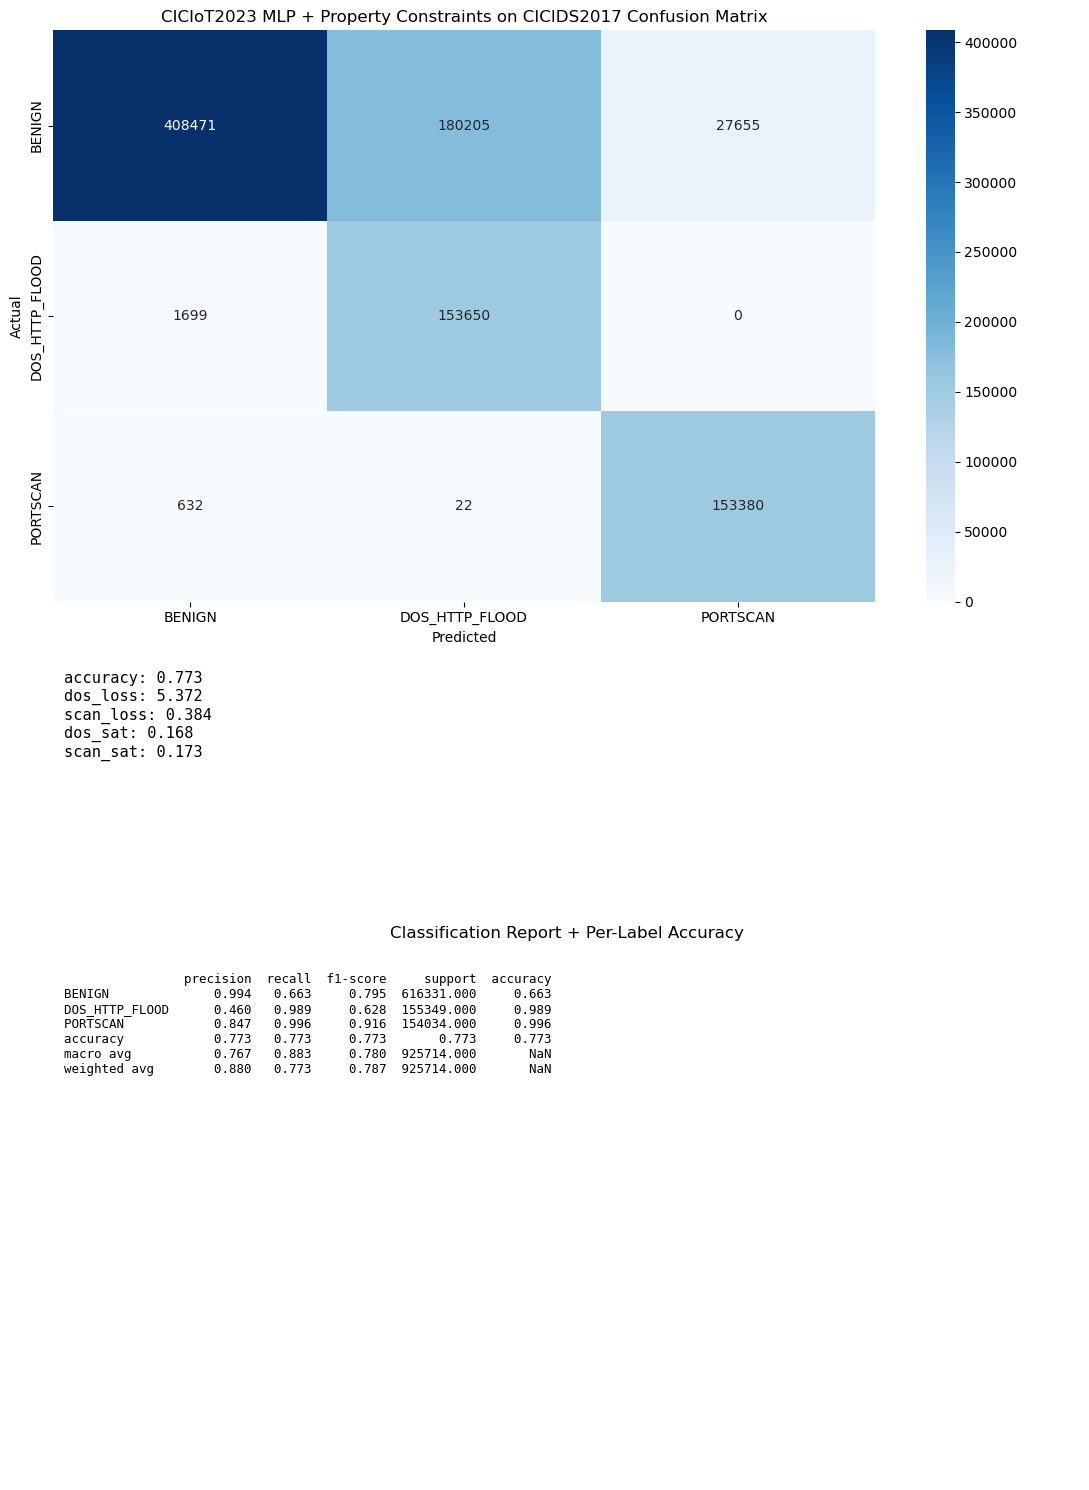

In [69]:
plot_eval_summary(
    metrics,
    report_df,
    cm,
    labels,
    model_name=f"{dataset_name} MLP + Property Constraints on {cross_eval_dataset_name}",
)